In [42]:
import cv2
import sys
from ultralytics import YOLO
import os
from IPython.display import display, Image
from IPython import display
display.clear_output()
import numpy as np
import random
import PIL
import matplotlib.pyplot as plt

In [2]:
from yolo_main import COCOTrainer
from yolo_main import DataLoading

In [3]:
model = YOLO("yolo26s-seg.pt")


In [96]:
#image path
image_dir = '/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/emps_dataset/emps-DatasetNinja (2)/ds/test_dir/img/'
images = []
ann_list = []
i= 0
for img in os.listdir(image_dir):
    i+=1
    if random.uniform(0,1) > 0.999:
        images.append(np.array(PIL.Image.open(os.path.join(image_dir, img))))
        image = PIL.Image.open(os.path.join(image_dir, img))
        results = model(image , save = True)
        ann_frame = results[0].plot()
        ann_list.append(ann_frame)

        cv2.waitKey(5)
        cv2.imshow(str(i) , ann_frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break




In [97]:
cv2.destroyAllWindows()

In [13]:
loader = DataLoading(
    path="/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/ds",  # must contain img/ and ann/ subdirs
    output_dir="/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset",
    split_fraction = 0.998,
    val_fraction=0.2
)
loader.forward()

Number of images: 465
Number of annotations: 465
Successfully exported 372 items to /Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset/images/train/ + annotations/train_annotations.json
Successfully exported 92 items to /Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset/images/val/ + annotations/val_annotations.json
Successfully exported 1 items to /Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset/images/test/ + annotations/test_annotations.json


{'train': [('62594342ac.png', '62594342ac.png.json'),
  ('ce39bb3c03.png', 'ce39bb3c03.png.json'),
  ('a4b639ab1a.png', 'a4b639ab1a.png.json'),
  ('47286679c2.png', '47286679c2.png.json'),
  ('7d54a1c5b3.png', '7d54a1c5b3.png.json'),
  ('2dadb1ced1.png', '2dadb1ced1.png.json'),
  ('8d7fc4c578.png', '8d7fc4c578.png.json'),
  ('513158cf83.png', '513158cf83.png.json'),
  ('cf6823322f.png', 'cf6823322f.png.json'),
  ('ef6bbe7612.png', 'ef6bbe7612.png.json'),
  ('1b935635dd.png', '1b935635dd.png.json'),
  ('88808139d3.png', '88808139d3.png.json'),
  ('f98c5fb82a.png', 'f98c5fb82a.png.json'),
  ('c61a50a061.png', 'c61a50a061.png.json'),
  ('f659af19da.png', 'f659af19da.png.json'),
  ('cef2196885.png', 'cef2196885.png.json'),
  ('b2f6f1bbf9.png', 'b2f6f1bbf9.png.json'),
  ('2daa27a6df.png', '2daa27a6df.png.json'),
  ('62223ab32f.png', '62223ab32f.png.json'),
  ('5c418c2eb0.png', '5c418c2eb0.png.json'),
  ('2ee0518d7a.png', '2ee0518d7a.png.json'),
  ('ed120ef412.png', 'ed120ef412.png.json'),
 

In [14]:
import json

with open("/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset/annotations/train_annotations.json") as f:
    coco = json.load(f)

ann = coco["annotations"][0]
seg = ann["segmentation"]
print(type(seg))          # should be <class 'list'>, NOT dict
print(len(seg))
print(seg[0][:10] if isinstance(seg, list) else seg)

<class 'list'>
1
[193, 132, 192, 133, 190, 133, 186, 137, 186, 138]


In [18]:
from ultralytics.data.converter import convert_coco

convert_coco(
    labels_dir="/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset/annotations",  # directory containing your JSON files
    save_dir="/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/yolo_format_data",  # where to save converted labels
    use_segments=True,
    cls91to80=False,  # set False for custom datasets (see warning below)
)

Annotations /Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset/annotations/test_annotations.json: 100% ━━━━━━━━━━━━ 1/1 931.2it/s 0.0s
Annotations /Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset/annotations/train_annotations.json: 100% ━━━━━━━━━━━━ 372/372 835.1it/s 0.4s0.0s
Annotations /Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset/annotations/val_annotations.json: 100% ━━━━━━━━━━━━ 92/92 738.2it/s 0.1s0.1s
COCO data converted successfully.
Results saved to /Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/yolo_format_data


In [ ]:
# import shutil
# from pathlib import Path

# converted_dir = Path("/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset/converted/labels")
# dataset_dir = Path("/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset")

# # convert_coco names each subdirectory after its JSON file (minus the "instances_" prefix),
# # so iterate the actual subdirectories instead of assuming "train"/"val".
# for src in converted_dir.iterdir():
#     if not src.is_dir():
#         continue
#     dst = dataset_dir / "labels" / src.name
#     dst.mkdir(parents=True, exist_ok=True)
#     for f in src.glob("*.txt"):
#         shutil.move(str(f), str(dst / f.name))

FileNotFoundError: [Errno 2] No such file or directory: '/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset/converted/labels'

In [ ]:
# import shutil
# from pathlib import Path

# dataset_dir = Path("/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset")
# yolo_format_dir = Path("/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/yolo_format_data")

# rename_map = {
#     "train_annotations": "train",
#     "val_annotations": "val",
#     "test_annotations": "test",
# }

# for src_name, dst_name in rename_map.items():
#     src = yolo_format_dir / "labels" / src_name
#     if not src.exists():
#         print(f"skip: {src} not found")
#         continue
#     dst = dataset_dir / "labels" / dst_name
#     dst.parent.mkdir(parents=True, exist_ok=True)
#     if dst.exists():
#         shutil.rmtree(dst)
#     shutil.move(str(src), str(dst))
#     print(f"moved {src} -> {dst}")

# # clean up the now-empty scaffold convert_coco left behind
# shutil.rmtree(yolo_format_dir, ignore_errors=True)
# print(f"removed {yolo_format_dir}")

moved /Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/yolo_format_data/labels/train_annotations -> /Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset/labels/train
moved /Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/yolo_format_data/labels/val_annotations -> /Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset/labels/val
moved /Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/yolo_format_data/labels/test_annotations -> /Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset/labels/test
removed /Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/yolo_format_data


In [ ]:
# for split in ("train", "val"):
#     images = sorted((dataset_dir / "images" / split).glob("*"))
#     labels = sorted((dataset_dir / "labels" / split).glob("*.txt"))
#     img_stems = {p.stem for p in images}
#     label_stems = {p.stem for p in labels}
#     print(f"[{split}] images={len(images)} labels={len(labels)} unmatched={len(img_stems - label_stems)}")

# sample = next((dataset_dir / "labels" / "train").glob("*.txt"))
# line = sample.read_text().splitlines()[0]
# vals = line.split()
# print(f"values in first label line: {len(vals)}")  # should be odd, >5 — confirms polygon format, not box-only

[train] images=372 labels=372 unmatched=0
[val] images=92 labels=92 unmatched=0
values in first label line: 779


In [26]:
from ultralytics import YOLO
dataset_yaml = '/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset/dataset.yaml'
model = YOLO("yolo26s-seg.pt")  # load a pretrained model
results = model.train(data=dataset_yaml, epochs=20, imgsz=1024, device = 'cpu' ,batch=4,
    name="yolo_ft_v1",)

Ultralytics 8.4.93 🚀 Python-3.9.6 torch-2.5.1 CPU (Apple M3 Max)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset/dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_ft_v1-4, nbs

KeyboardInterrupt: 

In [ ]:
# import json
# from pathlib import Path
# import yaml

# DATASET_DIR = Path("/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset")
# ann_path = DATASET_DIR / "annotations" / "train_annotations.json"
# yaml_path = DATASET_DIR / "dataset.yaml"

# with open(ann_path) as f:
#     coco = json.load(f)

# categories = sorted(coco["categories"], key=lambda x: x["id"])
# names = {cat["id"]: str(cat["name"]) for cat in categories}
# if min(names) != 0:
#     names = {cat_id - min(names): name for cat_id, name in names.items()}

# dataset = {
#     "path": str(DATASET_DIR.resolve()),
#     "train": "images/train",
#     "val": "images/val",
#     "names": names,
# }

# with open(yaml_path, "w") as f:
#     yaml.safe_dump(dataset, f, default_flow_style=False, sort_keys=False, default_style="'")

# with open(yaml_path) as f:
#     reloaded = yaml.safe_load(f)
# assert reloaded["names"] == names
# print(reloaded)

{'path': '/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset', 'train': 'images/train', 'val': 'images/val', 'names': {0: 'particle'}}


In [ ]:
# import shutil
# from pathlib import Path

# dataset_dir = Path("/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset")

# # Rename labels/train_annotations -> labels/train, labels/val_annotations -> labels/val
# (dataset_dir / "labels" / "train_annotations").rename(dataset_dir / "labels" / "train")
# (dataset_dir / "labels" / "val_annotations").rename(dataset_dir / "labels" / "val")

# # Remove the stale duplicate from the earlier double-conversion
# shutil.rmtree(dataset_dir / "converted")

In [ ]:
# from pathlib import Path

# yolo_format_dir = Path("/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/yolo_format_data")
# for p in sorted(yolo_format_dir.rglob("*")):
#     if p.is_dir():
#         print(p)

/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/yolo_format_data/images
/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/yolo_format_data/labels
/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/yolo_format_data/labels/test_annotations
/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/yolo_format_data/labels/train_annotations
/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/yolo_format_data/labels/val_annotations


In [27]:
results = model.train(
    data=dataset_yaml,
    epochs=100,
    imgsz=1024,
    device='cpu',
    batch=4,
    name="yolo_ft_v1_100",
    patience=15,       # stop if val metrics don't improve for 10 consecutive epochs
    copy_paste=0.3,     # mild copy-paste augmentation, given your small (372-image) train set
)

Ultralytics 8.4.93 🚀 Python-3.9.6 torch-2.5.1 CPU (Apple M3 Max)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset/dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_ft_v1_100, 

In [256]:
image_dir = '/Users/tjsss/Desktop/bharatAtomic/semPhase1/dataset/crop/images/Particles'
images = []
ann_list = []
i= 0
for img in os.listdir(image_dir):
    i+=1
    if random.uniform(0,1) > 0.98 and len(ann_list) < 10:
        images.append(np.array(PIL.Image.open(os.path.join(image_dir, img))))
        image = PIL.Image.open(os.path.join(image_dir, img))
        results = model(image , save = True)
        ann_frame = results[0].plot(boxes = False, labels = False)
        ann_list.append(ann_frame)

        cv2.waitKey(5)
        cv2.imshow(str(i) , ann_frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break


0: 1024x1024 3 particles, 147.8ms
Speed: 6.4ms preprocess, 147.8ms inference, 1.9ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /Users/tjsss/Desktop/bharatAtomic/runs/segment/predict-3

0: 1024x1024 4 particles, 154.2ms
Speed: 2.1ms preprocess, 154.2ms inference, 2.2ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /Users/tjsss/Desktop/bharatAtomic/runs/segment/predict-3

0: 1024x1024 (no detections), 137.4ms
Speed: 2.1ms preprocess, 137.4ms inference, 0.1ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /Users/tjsss/Desktop/bharatAtomic/runs/segment/predict-3

0: 1024x1024 5 particles, 139.9ms
Speed: 2.3ms preprocess, 139.9ms inference, 2.7ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /Users/tjsss/Desktop/bharatAtomic/runs/segment/predict-3

0: 1024x1024 2 particles, 134.6ms
Speed: 2.1ms preprocess, 134.6ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /Users/t

In [255]:
cv2.destroyAllWindows()

In [106]:
pred = model('/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/emps_dataset/emps-DatasetNinja (2)/ds/img/611b9564a4.png' )


image 1/1 /Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/emps_dataset/emps-DatasetNinja (2)/ds/img/611b9564a4.png: 1024x1024 16 particles, 236.8ms
Speed: 5.4ms preprocess, 236.8ms inference, 7.3ms postprocess per image at shape (1, 3, 1024, 1024)


In [108]:
cv2.waitKey(5)
cv2.imshow('103', pred[0].plot())

In [144]:
import datetime
import shutil
from pathlib import Path
from collections import Counter

import yaml
import pandas as pd
from sklearn.model_selection import KFold
from tqdm import tqdm

DATASET_ROOT = Path("/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset")
IMG_EXTS = {".png", ".jpg", ".jpeg"}
SPLITS = ["train", "val", "test"]

assert DATASET_ROOT.exists(), f"DATASET_ROOT does not exist: {DATASET_ROOT}"

In [145]:
yaml_file = DATASET_ROOT / "dataset.yaml"
with open(yaml_file, encoding="utf8") as y:
    data_cfg = yaml.safe_load(y)

names = data_cfg["names"]
# handle both {0: 'particle'} and ['particle'] YAML formats defensively
classes = names if isinstance(names, dict) else {i: n for i, n in enumerate(names)}
cls_idx = sorted(classes.keys())
print("classes:", classes)

classes: {0: 'particle'}


In [146]:
labels, images = [], []
for split in SPLITS:
    labels.extend(sorted((DATASET_ROOT / "labels" / split).glob("*.txt")))
    for ext in IMG_EXTS:
        images.extend(sorted((DATASET_ROOT / "images" / split).glob(f"*{ext}")))

print(f"labels found: {len(labels)}")
print(f"images found: {len(images)}")

label_stems = {l.stem for l in labels}
image_stems = {i.stem for i in images}
assert label_stems == image_stems, (
    f"MISMATCH — labels w/o image: {label_stems - image_stems}, "
    f"images w/o label: {image_stems - label_stems}"
)
print("labels and images fully aligned:", len(labels), "pairs")

labels found: 465
images found: 465
labels and images fully aligned: 465 pairs


In [147]:
index = sorted(label_stems)  # stem-based index, order-independent downstream
labels_df = pd.DataFrame(0.0, columns=cls_idx, index=index)

label_by_stem = {l.stem: l for l in labels}
for stem, label_path in label_by_stem.items():
    counter = Counter()
    with open(label_path) as lf:
        for line in lf:
            counter[int(line.split(" ", 1)[0])] += 1
    for c, n in counter.items():
        labels_df.loc[stem, c] = n

In [148]:
ksplit = 5
kf = KFold(n_splits=ksplit, shuffle=True, random_state=20)
kfolds = list(kf.split(labels_df))

folds = [f"split_{n}" for n in range(1, ksplit + 1)]
folds_df = pd.DataFrame(index=index, columns=folds)

for i, (train_idx, val_idx) in enumerate(kfolds, start=1):
    folds_df[f"split_{i}"].loc[labels_df.iloc[train_idx].index] = "train"
    folds_df[f"split_{i}"].loc[labels_df.iloc[val_idx].index] = "val"

print(folds_df.apply(pd.Series.value_counts))

       split_1  split_2  split_3  split_4  split_5
train      372      372      372      372      372
val         93       93       93       93       93


/var/folders/jr/6f0bcbl178x_f0wc0s1rfdqr0000gn/T/ipykernel_67131/909702010.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  folds_df[f"split_{i}"].loc[labels_df.iloc[train_idx].index] = "train"
/var/folders/jr/6f0bcbl178x_f0wc0s1rfdqr0000

In [169]:
save_path = DATASET_ROOT / f"{datetime.date.today().isoformat()}_{ksplit}fold_cv"
if save_path.exists():
    shutil.rmtree(save_path)  # clean slate — don't merge into a stale prior run
save_path.mkdir(parents=True)

ds_yamls = []
for split in folds_df.columns:
    split_dir = save_path / split
    (split_dir / "train" / "images").mkdir(parents=True, exist_ok=True)
    (split_dir / "train" / "labels").mkdir(parents=True, exist_ok=True)
    (split_dir / "val" / "images").mkdir(parents=True, exist_ok=True)
    (split_dir / "val" / "labels").mkdir(parents=True, exist_ok=True)

    dataset_yaml = split_dir / f"{split}_dataset.yaml"
    ds_yamls.append(dataset_yaml)
    with open(dataset_yaml, "w") as f:
        yaml.safe_dump(
            {"path": split_dir.as_posix(), "train": "train", "val": "val", "names": classes},
            f,
        )

In [170]:
for fold_name, subset in folds_df.loc[stem].items():
    print(fold_name, subset)

split_1 train
split_2 val
split_3 train
split_4 train
split_5 train


In [171]:
image_by_stem = {p.stem: p for p in images}

for stem in tqdm(index, desc="Copying files"):
    image_path = image_by_stem[stem]
    label_path = label_by_stem[stem]
    for fold_name, subset in folds_df.loc[stem].items():
        img_to = save_path / fold_name / subset / "images"
        lbl_to = save_path / fold_name / subset / "labels"
        shutil.copy2(image_path, img_to / image_path.name)
        shutil.copy2(label_path, lbl_to / label_path.name)

folds_df.to_csv(save_path / "kfold_datasplit.csv")

Copying files: 100%|██████████| 465/465 [00:02<00:00, 210.83it/s]


In [172]:
print(f"{'fold':<10}{'train/images':<15}{'train/labels':<15}{'val/images':<15}{'val/labels':<15}")
all_ok = True
for split in folds_df.columns:
    split_dir = save_path / split
    counts = {}
    for sub in ["train/images", "train/labels", "val/images", "val/labels"]:
        n = len(list((split_dir / sub).glob("*")))
        counts[sub] = n
        if n == 0:
            all_ok = False
    print(f"{split:<10}{counts['train/images']:<15}{counts['train/labels']:<15}"
          f"{counts['val/images']:<15}{counts['val/labels']:<15}")
    assert counts["train/images"] == counts["train/labels"], f"{split}: train image/label count mismatch"
    assert counts["val/images"] == counts["val/labels"], f"{split}: val image/label count mismatch"
    assert counts["train/images"] + counts["val/images"] == len(index), f"{split}: total != {len(index)}"

# confirm every generated YAML actually resolves
for dataset_yaml in ds_yamls:
    with open(dataset_yaml) as f:
        cfg = yaml.safe_load(f)
    base = Path(cfg["path"])
    assert (base / cfg["train"]).exists(), f"{dataset_yaml}: train path missing"
    assert (base / cfg["val"]).exists(), f"{dataset_yaml}: val path missing"

print("ALL CHECKS PASSED" if all_ok else "CHECK FAILURES ABOVE — do not proceed to training")

fold      train/images   train/labels   val/images     val/labels     
split_1   372            372            93             93             
split_2   372            372            93             93             
split_3   372            372            93             93             
split_4   372            372            93             93             
split_5   372            372            93             93             
ALL CHECKS PASSED


In [173]:
epochs = 50
batch = 4
imgsz = 1024
project = "kfold_demo"

results_kfold = {}
for k, dataset_yaml in enumerate(ds_yamls, start=1):
    model = YOLO("yolo26s-seg.pt")  # fresh pretrained weights every fold — no cross-fold weight leakage
    results_kfold[k] = model.train(
        data=dataset_yaml,
        epochs=epochs,
        imgsz=imgsz,
        device="cpu",
        batch=batch,
        project=project,
        name=f"yolo_ft_v2_fold_{k}",
        patience=15,
        copy_paste=0.3,
    )

New https://pypi.org/project/ultralytics/8.4.95 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.93 🚀 Python-3.9.6 torch-2.5.1 CPU (Apple M3 Max)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset/2026-07-14_5fold_cv/split_1/split_1_dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, ma

In [174]:
import numpy as np

box_map = [r.box.map for r in results_kfold.values()]
seg_map = [r.seg.map for r in results_kfold.values()]

print(f"Box mAP50-95: {np.mean(box_map):.4f} ± {np.std(box_map):.4f}")
print(f"Mask mAP50-95: {np.mean(seg_map):.4f} ± {np.std(seg_map):.4f}")
print("per-fold mask mAP50-95:", [f"{v:.4f}" for v in seg_map])

Box mAP50-95: 0.7899 ± 0.0320
Mask mAP50-95: 0.7294 ± 0.0411
per-fold mask mAP50-95: ['0.7004', '0.6772', '0.7626', '0.7169', '0.7897']


In [ ]:
box_map50 = [r.box.map50 for r in results_kfold.values()]
seg_map50 = [r.seg.map50 for r in results_kfold.values()]

print(f"Box mAP@0.5: {np.mean(box_map50):.4f} ± {np.std(box_map50):.4f}")
print(f"Mask mAP@0.5: {np.mean(seg_map50):.4f} ± {np.std(seg_map50):.4f}")
print(per-)

Box mAP@0.5: 0.9534 ± 0.0292
Mask mAP@0.5: 0.9398 ± 0.0316


In [176]:
instance_count = labels_df.sum(axis=1)  # total particle instances per image (single-class)
density_bucket = pd.cut(instance_count, bins=[0, 3, 8, 100], labels=["sparse", "moderate", "dense"])

# per-fold: which val images are dense, and how did those specifically perform?
for i, results in results_kfold.items():
    split = f"split_{i}"
    val_stems = folds_df[folds_df[split] == "val"].index
    dense_val = [s for s in val_stems if density_bucket.get(s) == "dense"]
    print(f"fold {i}: {len(dense_val)} dense-cluster images in val set")

fold 1: 38 dense-cluster images in val set
fold 2: 38 dense-cluster images in val set
fold 3: 41 dense-cluster images in val set
fold 4: 45 dense-cluster images in val set
fold 5: 43 dense-cluster images in val set


## Saving the best and last weights

In [190]:
import torch
weight_paths = [
    '/Users/tjsss/Desktop/bharatAtomic/runs/segment/kfold_demo/yolo_ft_v2_fold_1/weights/best.pt',
    '/Users/tjsss/Desktop/bharatAtomic/runs/segment/kfold_demo/yolo_ft_v2_fold_2/weights/best.pt',
    '/Users/tjsss/Desktop/bharatAtomic/runs/segment/kfold_demo/yolo_ft_v2_fold_3/weights/best.pt',
    '/Users/tjsss/Desktop/bharatAtomic/runs/segment/kfold_demo/yolo_ft_v2_fold_4/weights/best.pt',
    '/Users/tjsss/Desktop/bharatAtomic/runs/segment/kfold_demo/yolo_ft_v2_fold_5/weights/best.pt'
]

ckpts = [torch.load(p, map_location = 'cpu') for p in weight_paths]

model_state_dicts = []
for ckpt in ckpts:
    if 'model' in ckpt:
        model_state_dicts.append(ckpt['model'].state_dict())
    else:
        models_state_dicts.append(ckpt)

    
averaged_state_dict = model_state_dicts[0].copy()

for key in averaged_state_dict:
    if averaged_state_dict[key].is_floating_point() or averaged_state_dict[key].is_complex():
        tensors = [sd[key].float() for sd in model_state_dicts]
        averaged_state_dict[key] = torch.stack(tensors).mean(dim = 0)

output_ckpt = ckpts[0].copy()
if 'model' in output_ckpt:
    output_ckpt['model'].load_state_dict(averaged_state_dict)
else:
    output_ckpt = averaged_state_dict

torch.save(output_ckpt, '/Users/tjsss/Desktop/bharatAtomic/runs/segment/kfold_demo/average_weights/best.pt',)
print('succesfully saved averaged weights')


/var/folders/jr/6f0bcbl178x_f0wc0s1rfdqr0000gn/T/ipykernel_67131/4169625438.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpts = [torch.load(p, map_location = 'cpu')

succesfully saved averaged weights


In [191]:
import torch
weight_paths = [
    '/Users/tjsss/Desktop/bharatAtomic/runs/segment/kfold_demo/yolo_ft_v2_fold_1/weights/last.pt',
    '/Users/tjsss/Desktop/bharatAtomic/runs/segment/kfold_demo/yolo_ft_v2_fold_2/weights/last.pt',
    '/Users/tjsss/Desktop/bharatAtomic/runs/segment/kfold_demo/yolo_ft_v2_fold_3/weights/last.pt',
    '/Users/tjsss/Desktop/bharatAtomic/runs/segment/kfold_demo/yolo_ft_v2_fold_4/weights/last.pt',
    '/Users/tjsss/Desktop/bharatAtomic/runs/segment/kfold_demo/yolo_ft_v2_fold_5/weights/last.pt'
]

ckpts = [torch.load(p, map_location = 'cpu') for p in weight_paths]

model_state_dicts = []
for ckpt in ckpts:
    if 'model' in ckpt:
        model_state_dicts.append(ckpt['model'].state_dict())
    else:
        models_state_dicts.append(ckpt)

    
averaged_state_dict = model_state_dicts[0].copy()

for key in averaged_state_dict:
    if averaged_state_dict[key].is_floating_point() or averaged_state_dict[key].is_complex():
        tensors = [sd[key].float() for sd in model_state_dicts]
        averaged_state_dict[key] = torch.stack(tensors).mean(dim = 0)

output_ckpt = ckpts[0].copy()
if 'model' in output_ckpt:
    output_ckpt['model'].load_state_dict(averaged_state_dict)
else:
    output_ckpt = averaged_state_dict

torch.save(output_ckpt, '/Users/tjsss/Desktop/bharatAtomic/runs/segment/kfold_demo/average_weights/last.pt',)
print('succesfully saved averaged weights')

/var/folders/jr/6f0bcbl178x_f0wc0s1rfdqr0000gn/T/ipykernel_67131/2865502094.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpts = [torch.load(p, map_location = 'cpu')

succesfully saved averaged weights


In [208]:
image_dir = '/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/emps_dataset/emps-DatasetNinja (2)/ds/test_dir/img/'
images = []
ann_list = []
i= 0
for img in os.listdir(image_dir):
    i+=1
    if random.uniform(0,1) > 0.98:
        images.append(np.array(PIL.Image.open(os.path.join(image_dir, img))))
        image = PIL.Image.open(os.path.join(image_dir, img))
        results = model(image , save = True, show_boxes = False)
        ann_frame = results[0].plot()
        ann_list.append(ann_frame)

        cv2.waitKey(5)
        cv2.imshow(str(i) , ann_frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break


0: 736x1024 19 particles, 669.5ms
Speed: 57.5ms preprocess, 669.5ms inference, 21.6ms postprocess per image at shape (1, 3, 736, 1024)
Results saved to /Users/tjsss/Desktop/bharatAtomic/runs/segment/predict-3

0: 800x1024 2 particles, 359.2ms
Speed: 2.8ms preprocess, 359.2ms inference, 4.0ms postprocess per image at shape (1, 3, 800, 1024)
Results saved to /Users/tjsss/Desktop/bharatAtomic/runs/segment/predict-3

0: 1024x1024 23 particles, 537.8ms
Speed: 2.8ms preprocess, 537.8ms inference, 31.2ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /Users/tjsss/Desktop/bharatAtomic/runs/segment/predict-3

0: 896x1024 32 particles, 478.6ms
Speed: 2.8ms preprocess, 478.6ms inference, 30.5ms postprocess per image at shape (1, 3, 896, 1024)
Results saved to /Users/tjsss/Desktop/bharatAtomic/runs/segment/predict-3

0: 640x1024 33 particles, 310.8ms
Speed: 3.8ms preprocess, 310.8ms inference, 21.6ms postprocess per image at shape (1, 3, 640, 1024)
Results saved to /Users/tjss

In [235]:
%matplotlib inline
img = '/Users/tjsss/Desktop/bharatAtomic/semPhase1/notebooks/images/images.jpeg'
image = PIL.Image.open(img)
result = model(image, save= False, show_boxes = False)
ann_frame= result[0].plot()

cv2.imshow(img.split('/' , -1)[-1].split('.',1)[0], ann_frame)
cv2.waitKey(1)




0: 704x1024 8 particles, 467.3ms
Speed: 9.9ms preprocess, 467.3ms inference, 5.4ms postprocess per image at shape (1, 3, 704, 1024)


-1

In [227]:
cv2.destroyAllWindows()



In [ ]:
images = []
i=0
image_dir = '/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/yolo/yolo_converted_data/dataset/images/val'
for img in os.listdir(image_dir):
    if random.uniform(0,1) > 0.70:
        image = PIL.Image.open(os.path.join(image_dir, img))
        detections = model.predict(image,save = False, show_boxes = False, show_labels = False)
        images.append(detections[0])



0: 1024x1024 8 particles, 156.5ms
Speed: 3.1ms preprocess, 156.5ms inference, 4.4ms postprocess per image at shape (1, 3, 1024, 1024)

0: 1024x1024 2 particles, 136.1ms
Speed: 5.3ms preprocess, 136.1ms inference, 1.5ms postprocess per image at shape (1, 3, 1024, 1024)

0: 704x1024 32 particles, 89.7ms
Speed: 1.8ms preprocess, 89.7ms inference, 11.2ms postprocess per image at shape (1, 3, 704, 1024)

0: 1024x1024 8 particles, 137.3ms
Speed: 2.3ms preprocess, 137.3ms inference, 4.1ms postprocess per image at shape (1, 3, 1024, 1024)

0: 896x1024 6 particles, 118.3ms
Speed: 2.2ms preprocess, 118.3ms inference, 2.8ms postprocess per image at shape (1, 3, 896, 1024)

0: 960x1024 7 particles, 130.9ms
Speed: 2.3ms preprocess, 130.9ms inference, 3.1ms postprocess per image at shape (1, 3, 960, 1024)

0: 864x1024 3 particles, 103.9ms
Speed: 2.1ms preprocess, 103.9ms inference, 1.7ms postprocess per image at shape (1, 3, 864, 1024)

0: 768x1024 55 particles, 100.1ms
Speed: 1.9ms preprocess, 100

TypeError: plot() got an unexpected keyword argument 'show_boxes'

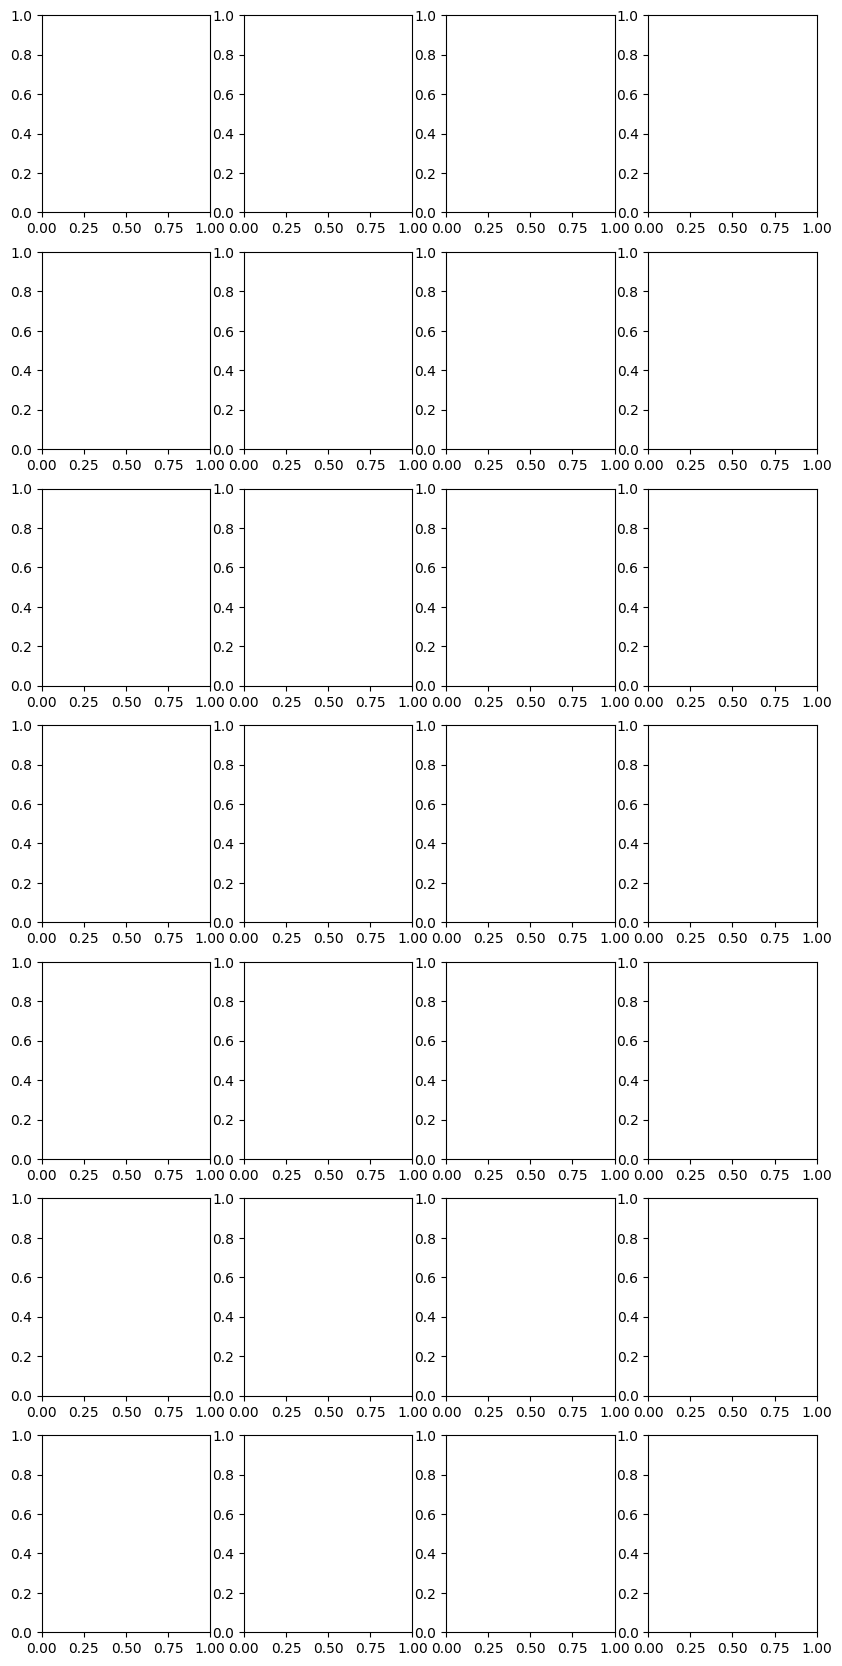

In [ ]:
import math

num_imgs = len(images)
cols = 4
rows = math.ceil(num_imgs/cols)

fig, ax = plt.subplots(rows, cols, figsize = (10, 3*rows))
ax = ax.flatten()

for i in range(len(ax)):
    if i<num_imgs:
        ax[i].imshow(images[i].plot())

    ax[i].axis('off')
plt.tight_layout()
plt.show(
)


0: 1024x1024 2 particles, 325.1ms
Speed: 16.1ms preprocess, 325.1ms inference, 1.9ms postprocess per image at shape (1, 3, 1024, 1024)


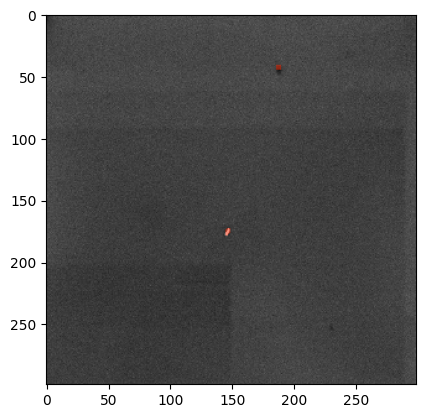

In [282]:
image = '/Users/tjsss/Desktop/bharatAtomic/semPhase1/dataset/crop/images/Particles/L2_ae689d5414295ee6379ddefa169657d4.jpg'
image = PIL.Image.open(image)
result = model.predict(image, save= False, show_boxes = False)
ann_frame= result[0].plot(labels=False, boxes = False)
plt.imshow(ann_frame)